# 01 Foundation Models

In this workbook we'll cover how to create and use foundation models for various providers.

The biggest advantage of LangChain is the ability to seamlessly use a of foundation models from a variety of providers, such as OpenAI, Anthropic and Google.


In [1]:
from dotenv import load_dotenv

load_dotenv(override=True)

True

The foundation of an agent is the model (LLM) within it. This is the the thinking brain of the Agent - the conductor of the orchestra. Interacting with a model using LangChain is fairly straightforward.

* You instantiate the model using `init_chat_model()` from `langchain.chat_models` model.
* Then you call the `invoke()` function on the instantiated mode, which takes your _user prompt_ (or query) and returns a _response_.
* The `response.content` property gives you the final response from the LLM.

In [2]:
from langchain.chat_models import init_chat_model

# NOTE: you must set the appropriate API key in the .env file
# in this example we'll be using OpenAIs GPT5 model
model = init_chat_model("openai:gpt-5-nano")
# ask the model a question
response = model.invoke("What is the capital of the moon?")

# display the response
from rich.console import Console  # pretty printing JSON/structured data

console = Console()
console.print(response)

AIMessage(
    content="There isn’t one. The Moon has no capital because it isn’t a country or a city—it's a natural satellite
of Earth. If you’re feeling playful, you could imagine a fictional capital named something like “Lunapolis” or 
“Selene City.”",
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 574,
            'prompt_tokens': 14,
            'total_tokens': 588,
            'completion_tokens_details': {
                'accepted_prediction_tokens': 0,
                'audio_tokens': 0,
                'reasoning_tokens': 512,
                'rejected_prediction_tokens': 0
            },
            'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}
        },
        'model_provider': 'openai',
        'model_name': 'gpt-5-nano-2025-08-07',
        'system_fingerprint': None,
        'id': 'chatcmpl-DUA9X1Ws04h09o8rk6t1S4eX0kJo7',
        'service_tier': 'default',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--019d86b0-f310-7fc2-a6b1-89147efe9197-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 14,
        'output_tokens': 574,
        'total_tokens': 588,
        'input_token_details': {'audio': 0, 'cache_read': 0},
        'output_token_details': {'audio': 0, 'reasoning': 512}
    }
)

Notice that `response` is an `AIMessage`, which has the _final answer_ from the model in the `content` key. A lot of additional meta-data is also returned as part of the overall JSON response, which can be pretty useful. Information such as model & model provider or token information returned as part of the `usage_metadata` key.

In most cases, `response.content` is what we are interested in, and it can be printed as follows. This is how we will interact with the model in most cases.

In [3]:
print(response.content)

There isn’t one. The Moon has no capital because it isn’t a country or a city—it's a natural satellite of Earth. If you’re feeling playful, you could imagine a fictional capital named something like “Lunapolis” or “Selene City.”


We can customize the model by adjusting some parameters we pass into the `init_chat_model()` call. We did not use these before as most of them have reasonable defaults. Here are the params we could adjust:
* `temperature`: controls the randomness of the model's response. Higher this number, makes model's responses more creative, whereas lower numbers make it more deterministic. For _creative_ applications (such as generation of poetry or creative imagery), I'll use a higher value (towards 1) and for most business applications I'll use value towards (or = 0).
* `max_tokens`: defines the max number of tokens we can get in the response, effectively controlling how long the output from the model can be.
* `timeout`: defines the MAX time to wait for a response from the model before cancelling the request. 
* `max_retries`: maximum amount of times to retry, should the request fail.

Now let's see how the model responds when temperature is set to a _large_ value.

In [4]:
model2 = init_chat_model("openai:gpt-5-nano", temperature=1.0)
response = model2.invoke("What is the capital of the moon?")
print(response.content)

There isn’t one. The Moon isn’t a country and has no government or capital.

If you were going for a wordplay answer: the capital (uppercase) letter of the word “Moon” is M.


LangChain supports a lot of models - for a complete list see [Chat Model Integrators](https://docs.langchain.com/oss/python/integrations/chat). Each model will usually requires it's own API key to be created and then set in the `.env` file. For example, to use Anthropic's Haiku 4.6 model, I'll need to set ANTHROPIC_API_KEY in my `.env` and instantiate the model as below.

Notice that apart from the model's name, rest of the code is exactly the same as above!!

The beauty of LangChain is that it is model agnostic. _In most cases_, switching from one model to another is as easy as changing the model provider string provided to the `init_chat_model()` function (provided of course, that you have the corresponding API key defined in the `.env` file.). In some cases, such as Google Gemini, you may need to use the model's Langchain API library - see examples below.

In [5]:
# switching to Anthropic's Claude Sonnet library
# NOTE: you'll need to get an API key from Anthropic's website and define
# an ANTHROPIC_API_KEY=XXXX entry in your .env file
haiku = init_chat_model("anthropic:claude-haiku-4-5", temperature=1.0)
response = haiku.invoke("What is the capital of the moon?")
print(response.content)

The Moon doesn't have a capital because it has no government, population, or cities. It's a natural satellite of Earth with no permanent human settlements.

If you're thinking of a fictional or imaginative scenario, I'd be happy to discuss that! Or if you meant to ask about something else related to the Moon, feel free to let me know.


In [ ]:
# using Google Gemini is a bit more detailed
# NOTE: you'll need to get an API key from Anthropic's website and define
# an GOOGLE_API_KEY=XXXX entry in your .env file
from langchain_google_genai import ChatGoogleGenerativeAI

gemini = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=1.0)
response = gemini.invoke("What is the capital of the moon?")
print(response.content)

## Building an Agent with LangChain

In [8]:
from langchain.agents import create_agent

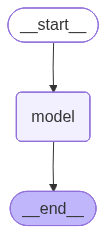

In [9]:
agent = create_agent(model="openai:gpt-5-nano")
agent

In [12]:
# ask the agent a question
query = "What's the capital of the Moon?"
response = agent.invoke(
    {"messages": [{"role": "user", "content": query}]},
)
# grab the last message
print(response["messages"][-1].content)

There isn’t one. The Moon has no government or capital. It’s a natural satellite of Earth. (In science fiction or future plans, a settlement might designate a capital, but none currently exists.)


In [21]:
# alternate way using specific AIMessage & HumanMessage
from langchain_core.messages import HumanMessage, AIMessage

human_query = HumanMessage("What's the capital of the moon?")

response = agent.invoke(
    {"messages": [HumanMessage(content="What's the capital of the Moon?")]}
)
print(response["messages"][-1].content)

There isn’t one. The Moon has no government or sovereignty, so it has no capital. If you’re thinking of a fictional setting, you could invent a capital city name like Luna City, Selene, or Artemis Prime. Want me to brainstorm ideas for a sci‑fi world?


In [22]:
# simulate a chat with the LLM
response = agent.invoke(
    {
        "messages": [
            HumanMessage(content="What's the capital of the Moon?"),
            AIMessage(content="The capital of the Moon is Luna City."),
            HumanMessage(content="Interesting, tell me more about Luna City"),
        ]
    }
)
print(response["messages"][-1].content)

Important note: Luna City is fictional. There is no real capital on the Moon, but if you’re building a story or game, here’s a fleshed-out concept you can use.

Overview
- Location: A sprawling urban core that sits along the edge of Mare Tranquillitatis, built around a network of lava-tube hubs and crater rims. The city blends shielded domes with tunneled corridors that connect districts while keeping residents in pressurized, Earth-like climates.
- Role: Political, economic, and cultural center of a federated lunar civilization. It’s the “capital” of a Moon-wide confederation of settlements, research bases, and mining outposts.

Government and society
- Government: The Lunar Confederation, governed by a Council of Districts and an executive Director-General. Decisions are made in the Beacon Dome, a transparent geodesic hub that doubles as a broadcast center and civic forum.
- Civic life: Residents live in enclosed habitats connected by air-filled corridors and surface tram lines. Work

### Streaming Outputs

In [23]:
for token, metadata in agent.stream(
    {
        "messages": [
            HumanMessage(content="Tell me all about Luna City, the capital of the Moon")
        ]
    },
    stream_mode="messages",
):

    # token is a message chunk with token content
    # metadata contains which node produced the token

    if token.content:  # Check if there's actual content
        print(token.content, end="", flush=True)  # Print token

Here’s a detailed, self-contained concept for Luna City, the capital of the Moon. It’s built for world-building, storytelling, or game design. If you want a harder sci‑fi version or something more fantastical, tell me and I’ll tailor it.

Overview
- Name: Luna City (also called Selene Prime in diplomatic circles)
- Role: Capital of the Moon, political heart of the Lunar Confederation (a federated lunar government with Earth relations). Seat of the Lunar Council, judiciary, and most major universities and cultural institutions.
- Population: A few million residents across surface habitats, underground districts, and orbital platforms connected to the city. A steady flow of visitors and workers from Earth and other space habitats.
- Tone: A balanced blend of pragmatic engineering, high-tech diplomacy, and everyday lunar life. It works as a hub for science, commerce, culture, and governance in cislunar space.

Location and layout
- Geography: On/near the southern polar region, perched alo